In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import altair as alt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

# Enable Altair's data transformer for large datasets
alt.data_transformers.enable('default', max_rows=None)
alt.renderers.enable('default')

RendererRegistry.enable('default')

In [2]:
# load the clustering data for feature selection and clustering steps
selected_features_minus_noise = pd.read_csv('../../data/clustering/selected_features_minus_noise.csv')
pre_covid_sf_minus_noise = pd.read_csv('../../data/clustering/pre_covid_sf_minus_noise.csv')
covid_sf_minus_noise = pd.read_csv('../../data/clustering/covid_sf_minus_noise.csv')
post_covid_sf_minus_noise = pd.read_csv('../../data/clustering/post_covid_sf_minus_noise.csv')

feature_cols = [col for col in selected_features_minus_noise.columns if col not in ['Ticker', 'Company', 'Industrykey', 'Category']]
reduced_X_scaled_minus_noise = selected_features_minus_noise[feature_cols].values

selected_features_minus_noise

,Ticker,Company,Industrykey,Category,Avg_EPS_Change_4Q_mean,Avg_NIL_Change_4Q_mean,NetWorth_Change_mean,NetWorth_Volatility_2Q_max,Volume_accum_max,MarketCap_max,MarketCap_min,Volume_Change_std,EPS_Volatility_2Q_max,Return_mean,Volatility_2Q_max,Return_skew
0,A,Agilent Technologies,diagnostics-research,sp500,-0.074319,6.700387,-0.405524,-0.225121,-0.212947,0.005373,0.230229,-0.530947,0.032079,0.091116,-0.483583,0.096011
1,ABBV,AbbVie,drug-manufacturers-general,sp500,0.471005,1.365362,0.804841,0.141936,1.103978,5.141489,3.054615,0.113301,0.245468,0.501265,-0.340969,0.625311
2,ABNB,Airbnb,travel-services,sp500,10.062758,6.622816,1.399025,-0.003276,0.396645,1.025774,0.886592,-1.021104,1.295086,-1.224523,0.443060,-0.228790
3,ABT,Abbott Laboratories,medical-devices,sp500,0.483923,0.358919,0.157517,0.212518,0.852305,3.002510,2.335430,0.588628,0.069050,-0.120219,-0.632660,0.119558
4,ACGL,Arch Capital Group,insurance-diversified,sp500,0.213952,0.183678,0.374298,0.012921,-0.229294,-0.103846,-0.372054,0.492001,-0.224344,0.062081,-0.544021,-0.042162
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
477,XYZ,"Block, Inc.",software-infrastructure,sp500,1.104271,1.291777,3.952880,1.827585,1.757268,0.930182,-0.429047,1.896908,0.632924,2.140524,2.206236,0.889636
478,YUM,Yum! Brands,restaurants,sp500,0.102694,0.048093,-4.588531,3.138669,-0.010206,0.025074,0.611233,-0.281343,-0.203654,-0.228233,0.202192,-0.663324
479,ZBH,Zimmer Biomet,medical-devices,sp500,1.987892,1.698982,-0.033517,-0.060907,-0.255237,-0.184204,0.371389,0.184212,3.085408,-1.115613,-0.094687,-0.645382
480,ZBRA,Zebra Technologies,communication-equipment,sp500,-0.679580,-0.385075,0.426374,-0.026450,-0.436228,-0.261039,-0.335156,0.079199,0.349598,0.295716,0.494562,0.395537


In [3]:
def compute_kmeans_metrics(X, k_range=range(2, 10)):
    """Run KMeans for each k and return metric lists + numpy arrays."""
    inertias, silhouette_scores, davies_bouldin_scores, calinski_harabasz_scores = [], [], [], []
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X)
        inertias.append(kmeans.inertia_)
        silhouette_scores.append(silhouette_score(X, labels))
        davies_bouldin_scores.append(davies_bouldin_score(X, labels))
        calinski_harabasz_scores.append(calinski_harabasz_score(X, labels))
    return (
        inertias, silhouette_scores, davies_bouldin_scores, calinski_harabasz_scores,
        np.array(inertias), np.array(silhouette_scores),
        np.array(davies_bouldin_scores), np.array(calinski_harabasz_scores)
    )


def build_metric_dataframes(k_range, inertias, silhouette_scores, davies_bouldin_scores, calinski_harabasz_scores):
    """Build inertia and shared-metrics DataFrames for charting."""
    k_list = list(k_range)
    inertia_df = pd.DataFrame({'k': k_list, 'Inertia': inertias})
    shared_metrics_df = pd.DataFrame([
        {'k': k, 'Method': 'K-Means', 'Silhouette': s, 'Davies-Bouldin': d, 'Calinski-Harabasz': c}
        for k, s, d, c in zip(k_list, silhouette_scores, davies_bouldin_scores, calinski_harabasz_scores)
    ])
    return inertia_df, shared_metrics_df


def plot_kmeans_metrics(inertia_df, shared_metrics_df):
    """Return a 2×2 Altair grid of KMeans evaluation metric charts."""
    method_color = alt.Color(
        'Method:N',
        scale=alt.Scale(domain=['K-Means'], range=['#4C78A8']),
        title='Method', legend=None
    )
    base_km     = alt.Chart(inertia_df).encode(
        x=alt.X('k:O', title='Number of Clusters (k)', axis=alt.Axis(labelAngle=0))
    )
    base_shared = alt.Chart(shared_metrics_df).encode(
        x=alt.X('k:O', title='Number of Clusters (k / n)', axis=alt.Axis(labelAngle=0)),
        color=method_color
    )
    elbow = base_km.mark_line(point=True, color='#4C78A8').encode(
        y=alt.Y('Inertia:Q', title='Inertia', scale=alt.Scale(zero=False)),
        tooltip=['k', 'Inertia']
    ).properties(title='Elbow Method / Inertia  (K-Means Only)', width=alt.Step(60), height=300)

    silhouette_chart = base_shared.mark_line(point=True).encode(
        y=alt.Y('Silhouette:Q', title='Silhouette Score', scale=alt.Scale(zero=False)),
        tooltip=['k', 'Method', 'Silhouette']
    ).properties(title='Silhouette Score (Higher is Better)', width=alt.Step(60), height=300)

    davies_chart = base_shared.mark_line(point=True).encode(
        y=alt.Y('Davies-Bouldin:Q', title='Davies-Bouldin Index', scale=alt.Scale(zero=False)),
        tooltip=['k', 'Method', 'Davies-Bouldin']
    ).properties(title='Davies-Bouldin Index (Lower is Better)', width=alt.Step(60), height=300)

    calinski_chart = base_shared.mark_line(point=True).encode(
        y=alt.Y('Calinski-Harabasz:Q', title='Calinski-Harabasz Score', scale=alt.Scale(zero=False)),
        tooltip=['k', 'Method', 'Calinski-Harabasz']
    ).properties(title='Calinski-Harabasz Score (Higher is Better)', width=alt.Step(60), height=300)

    return (
        (elbow | silhouette_chart) & (davies_chart | calinski_chart)
    ).resolve_scale(y='independent').configure_axis(
        labelFontSize=14,
        titleFontSize=14,
    ).configure_title(fontSize=18)


k_range = range(2, 10)

(inertias, silhouette_scores, davies_bouldin_scores, calinski_harabasz_scores,
 inertias_arr, silhouette_arr, db_arr, ch_arr) = compute_kmeans_metrics(reduced_X_scaled_minus_noise, k_range)

inertia_df, shared_metrics_df = build_metric_dataframes(
    k_range, inertias, silhouette_scores, davies_bouldin_scores, calinski_harabasz_scores
)

plot_kmeans_metrics(inertia_df, shared_metrics_df)


alt.VConcatChart(...)

In [4]:

def minmax(x):
    x = np.array(x)
    return (x - np.nanmin(x)) / (np.nanmax(x) - np.nanmin(x))


def compute_combined_score(inertias, silhouette_scores, db_scores, ch_scores):
    """Normalize and combine four K-Means metrics into a single score (higher is better)."""
    norm_inertia    = 1 - minmax(inertias)      # lower is better → invert
    norm_silhouette = minmax(silhouette_scores)
    norm_db         = 1 - minmax(db_scores)     # lower is better → invert
    norm_ch         = minmax(ch_scores)
    return (norm_inertia + norm_silhouette + norm_db + norm_ch) / 4


def build_metrics_df(k_range, inertias, silhouette_scores, db_scores, ch_scores, combined_score):
    """Build a summary DataFrame of all K-Means evaluation metrics."""
    return pd.DataFrame({
        'k': list(k_range),
        'Inertia': inertias,
        'Silhouette': silhouette_scores,
        'Davies-Bouldin': db_scores,
        'Calinski-Harabasz': ch_scores,
        'Combined_Score': combined_score
    })


def select_optimal_k(k_range, combined_score, top_n=4):
    """Return the top-n k values by combined score and the single best k."""
    top_idx = np.argsort(combined_score)[-top_n:][::-1]
    top_k   = [list(k_range)[i] for i in top_idx]
    return top_k, top_k[0]


def find_optimal_k(X_data, k_range=range(2, 10)):
    """Find optimal k for a dataset using combined normalized metrics."""
    inertias_era, silhouette_era, db_era, ch_era = [], [], [], []
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X_data)
        inertias_era.append(kmeans.inertia_)
        silhouette_era.append(silhouette_score(X_data, labels))
        db_era.append(davies_bouldin_score(X_data, labels))
        ch_era.append(calinski_harabasz_score(X_data, labels))
    combined_era = compute_combined_score(inertias_era, silhouette_era, db_era, ch_era)
    return list(k_range)[np.argmax(combined_era)]


def apply_kmeans(X, n_clusters):
    """Fit KMeans and return (model, labels)."""
    model = KMeans(n_clusters=n_clusters, random_state=42, n_init=20)
    labels = model.fit_predict(X)
    return model, labels


def plot_combined_score(k_range, combined_score):
    """Return an Altair chart of the combined normalized score vs k."""
    df = pd.DataFrame([
        {'k': k, 'Method': 'K-Means', 'Combined_Score': s}
        for k, s in zip(list(k_range), combined_score)
    ])
    return (
        alt.Chart(df).mark_line(point=True).encode(
            x=alt.X('k:O', title='Number of Clusters (k / n)', axis=alt.Axis(labelAngle=0)),
            y=alt.Y('Combined_Score:Q', title='Combined Score (Normalized)', scale=alt.Scale(zero=False)),
            color=alt.Color(
                'Method:N',
                scale=alt.Scale(domain=['K-Means'], range=['#4C78A8']),
                title='Method'
            ),
            tooltip=['k', 'Method', alt.Tooltip('Combined_Score:Q', format='.4f')]
        ).properties(
            title='Combined Normalized Score — K-Means (Higher is Better)',
            width=alt.Step(60),
            height=320
        ).configure_axis(
            labelFontSize=14,
            titleFontSize=14,
        ).configure_title(
            fontSize=18
        )
    )

combined_score = compute_combined_score(inertias_arr, silhouette_arr, db_arr, ch_arr)
metrics_df     = build_metrics_df(k_range, inertias, silhouette_scores, davies_bouldin_scores,
                                   calinski_harabasz_scores, combined_score)
top_k, optimal_k = select_optimal_k(k_range, combined_score)

_, kmeans_labels = apply_kmeans(reduced_X_scaled_minus_noise, optimal_k)
selected_features_minus_noise['KMeans_Cluster'] = kmeans_labels

print("K-Means Metrics Summary:")
print(metrics_df.to_string(index=False))
print(f"\nTop 4 k by combined normalized metrics (K-Means): {top_k}")
print(f"Optimal k selected for K-Means: {optimal_k}")

# Calculate optimal k for each era
era_datasets_raw = {
    'All Periods':           selected_features_minus_noise,
    'Pre-COVID (~2015-2019)': pre_covid_sf_minus_noise,
    'COVID (2020-2022)':     covid_sf_minus_noise,
    'Post-COVID (2023-2025)': post_covid_sf_minus_noise
}

era_optimal_k = {}
print("\n" + "="*70)
print("Finding optimal k for each era:")
for era_name, era_df in era_datasets_raw.items():
    era_feature_cols = [col for col in era_df.columns if col not in ['Ticker', 'Company', 'Industrykey', 'Category']]
    era_optimal_k[era_name] = find_optimal_k(era_df[era_feature_cols].values)
    print(f"  {era_name}: k = {era_optimal_k[era_name]}")
print("="*70)

plot_combined_score(k_range, combined_score)


K-Means Metrics Summary:
 k      Inertia  Silhouette  Davies-Bouldin  Calinski-Harabasz  Combined_Score
 2 40075.199361    0.795768        0.757619          76.608967        0.553205
 3 36194.228660    0.697949        0.719125          68.004053        0.488239
 4 31633.236601    0.597720        1.235822          74.737696        0.288866
 5 27814.586628    0.559533        1.207877          79.987200        0.367117
 6 23935.646605    0.583820        0.967532          89.631691        0.620441
 7 21099.497708    0.585977        0.816658          95.196559        0.772497
 8 19056.823570    0.371072        0.905904          97.411326        0.650189
 9 17492.030375    0.348898        0.933601          97.953080        0.646227

Top 4 k by combined normalized metrics (K-Means): [7, 8, 9, 6]
Optimal k selected for K-Means: 7

Finding optimal k for each era:
  All Periods: k = 7
  Pre-COVID (~2015-2019): k = 7
  COVID (2020-2022): k = 5
  Post-COVID (2023-2025): k = 4


alt.Chart(...)

In [5]:
# Function to plot PCA explained variance
def plot_pca_explained_variance(X):
    pca_full = PCA(random_state=42)
    pca_full.fit(X)
    cumsum_variance = np.cumsum(pca_full.explained_variance_ratio_)
    explained_df = pd.DataFrame({
        'Component': np.arange(1, len(cumsum_variance) + 1),
        'CumulativeVariance': cumsum_variance
    })

    return alt.Chart(explained_df).mark_line(point=True).encode(
        x=alt.X('Component:O', title='Number of Components'),
        y=alt.Y('CumulativeVariance:Q', title='Cumulative Explained Variance', scale=alt.Scale(zero=False)),
        tooltip=['Component', alt.Tooltip('CumulativeVariance:Q', format='.2%')]
        ).properties(
            title='PCA Cumulative Explained Variance',
            width=alt.Step(40),
            height=300
        ).configure_axis(
        labelFontSize=14,
        titleFontSize=14,
        labelAngle=0
        ).configure_title(
            fontSize=18
        )
        
plot_pca_explained_variance(reduced_X_scaled_minus_noise)

alt.Chart(...)

In [6]:

HIGHLIGHT_CATS  = {'gig-work', 'mlm-work'}
_CAT_COLOR_MAP  = {'gig-work': '#4C4441', 'mlm-work': '#9C755F'}
PALETTE = [
    '#4C78A8', '#F58518', '#54A24B', '#E45756',
    '#22B6B2', '#FFB5B8', '#9E7BB5', '#B0B0B0',
    '#FFEF6B', '#FF1DA7',
]
META_COLS = ['Ticker', 'Company', 'Industrykey', 'Category']


def build_era_pca_df(era_datasets_raw, era_optimal_k, pca_vis, X_pca_all, feature_cols):
    """Project each era's data into PCA space, run KMeans, and return a combined DataFrame."""
    rows = []
    for era_name, era_df in era_datasets_raw.items():
        era_feature_cols = [c for c in era_df.columns if c not in META_COLS]
        era_X = era_df[era_feature_cols].values
        k_for_era = era_optimal_k[era_name]

        era_labels = KMeans(n_clusters=k_for_era, random_state=42, n_init=20).fit_predict(era_X)
        era_X_pca  = X_pca_all if era_name == 'All Periods' else pca_vis.transform(era_X)

        era_rows = pd.DataFrame(era_X_pca, columns=['PC1', 'PC2'])
        era_rows['Ticker']       = era_df['Ticker'].values
        era_rows['Company']      = era_df['Company'].values
        era_rows['Category']     = era_df['Category'].values
        era_rows['Industrykey']  = era_df['Industrykey'].values
        era_rows['Cluster']      = era_labels.astype(str)
        era_rows['ClusterLabel'] = 'Cluster ' + era_rows['Cluster']
        era_rows['Era']          = era_name
        era_rows['OptimalK']     = k_for_era
        for col in feature_cols[:3]:
            if col in era_df.columns:
                era_rows[col] = era_df[col].values
        rows.append(era_rows)

    return pd.concat(rows, ignore_index=True)


def build_centroids_df(combined_pca_df):
    """Compute per-era cluster centroid coordinates."""
    centroid_rows = []
    for era_name in combined_pca_df['Era'].unique():
        era_data = combined_pca_df[combined_pca_df['Era'] == era_name]
        for cid in sorted(era_data['Cluster'].unique()):
            cluster_data = era_data[era_data['Cluster'] == cid]
            centroid_rows.append({
                'PC1': cluster_data['PC1'].mean(),
                'PC2': cluster_data['PC2'].mean(),
                'Cluster': cid,
                'ClusterLabel': f'Cluster {cid}',
                'Era': era_name
            })
    return pd.DataFrame(centroid_rows)


def build_highlight_df(combined_pca_df, ref_df):
    """Return rows for highlighted tickers (gig-work & mlm-work) with their display color."""
    ticker_color_map = (
        ref_df[ref_df['Category'].isin(HIGHLIGHT_CATS)]
        .set_index('Ticker')['Category']
        .map(_CAT_COLOR_MAP)
        .to_dict()
    )
    highlight = combined_pca_df[combined_pca_df['Ticker'].isin(ticker_color_map)].copy()
    highlight['HighlightColor'] = highlight['Ticker'].map(ticker_color_map)
    return highlight


def plot_clustering_vis(combined_pca_df, centroids_vis_df, highlight_rows, era_optimal_k, pca_vis, feature_cols):
    """Return the interactive Altair PCA scatter chart with era toggle and cluster selection."""
    cluster_scale = alt.Scale(range=PALETTE)
    cluster_sel   = alt.selection_point(fields=['Cluster'])
    era_param     = alt.param(
        name='era_selection', value='All Periods',
        bind=alt.binding_radio(
            options=['All Periods', 'Pre-COVID (~2015-2019)', 'COVID (2020-2022)', 'Post-COVID (2023-2025)'],
            name='Time Period: '
        )
    )
    era_filter = alt.datum.Era == era_param

    # Secondary color scale for highlighted categories (legend-only layer)
    highlight_cat_scale = alt.Scale(
        domain=list(_CAT_COLOR_MAP.keys()),
        range=list(_CAT_COLOR_MAP.values())
    )

    halo = alt.Chart(combined_pca_df).mark_circle(opacity=0.08).encode(
        x='PC1:Q', y='PC2:Q',
        color=alt.Color('Cluster:N', scale=cluster_scale, legend=None),
        size=alt.condition(cluster_sel, alt.value(2800), alt.value(800))
    ).transform_filter(era_filter)

    scatter_vis = alt.Chart(combined_pca_df).mark_circle(stroke='white', strokeWidth=1.2).encode(
        x=alt.X('PC1:Q',
                title=f'PC1  –  {pca_vis.explained_variance_ratio_[0]:.1%} variance explained',
                axis=alt.Axis(grid=True, gridColor='#EBEBEB', tickCount=6)),
        y=alt.Y('PC2:Q',
                title=f'PC2  –  {pca_vis.explained_variance_ratio_[1]:.1%} variance explained',
                axis=alt.Axis(grid=True, gridColor='#EBEBEB', tickCount=6)),
        color=alt.Color('Cluster:N', scale=cluster_scale, title='Cluster'),
        size=alt.condition(cluster_sel, alt.value(280), alt.value(120)),
        opacity=alt.condition(cluster_sel, alt.value(0.92), alt.value(0.28)),
        tooltip=[
            alt.Tooltip('Company:N',      title='Company'),
            alt.Tooltip('Category:N',     title='Category'),
            alt.Tooltip('ClusterLabel:N', title='Cluster'),
            alt.Tooltip(feature_cols[0] + ':Q', title=feature_cols[0], format='.4f'),
            alt.Tooltip(feature_cols[1] + ':Q', title=feature_cols[1], format='.4f'),
            alt.Tooltip(feature_cols[2] + ':Q', title=feature_cols[2], format='.4f'),
        ]
    ).transform_filter(era_filter)

    text_vis = alt.Chart(combined_pca_df).mark_text(
        fontSize=9, fontWeight=300, dy=-12, color='#444444'
    ).encode(
        x='PC1:Q', y='PC2:Q',
        text=alt.Text('Ticker:N'),
        opacity=alt.condition(cluster_sel, alt.value(0.85), alt.value(0.0))
    ).transform_filter(era_filter)

    centroid_outer = alt.Chart(centroids_vis_df).mark_point(
        shape='diamond', filled=True, size=480, opacity=0.25
    ).encode(
        x='PC1:Q', y='PC2:Q',
        color=alt.Color('Cluster:N', scale=cluster_scale, legend=None)
    ).transform_filter(era_filter)

    centroid_inner = alt.Chart(centroids_vis_df).mark_point(
        shape='diamond', filled=True, size=180, stroke='white', strokeWidth=2
    ).encode(
        x='PC1:Q', y='PC2:Q',
        color=alt.Color('Cluster:N', scale=cluster_scale, legend=None),
        tooltip=[alt.Tooltip('ClusterLabel:N', title='Centroid')]
    ).transform_filter(era_filter)

    # Highlight drawing layers — use raw hex (HighlightColor:N, scale=None) to avoid
    # interfering with the cluster color scale resolution
    highlight_glow = alt.Chart(highlight_rows).mark_circle(opacity=0.22, strokeWidth=0).encode(
        x='PC1:Q', y='PC2:Q',
        color=alt.Color('HighlightColor:N', scale=None, legend=None),
        size=alt.value(1400)
    ).transform_filter(era_filter)

    highlight_pts = alt.Chart(highlight_rows).mark_circle(strokeWidth=2.8, filled=True).encode(
        x='PC1:Q', y='PC2:Q',
        color=alt.Color('HighlightColor:N', scale=None, legend=None),
        stroke=alt.value('white'),
        size=alt.value(310),
        opacity=alt.value(0.95),
        tooltip=[
            alt.Tooltip('Company:N',      title='Company'),
            alt.Tooltip('Category:N',     title='Category'),
            alt.Tooltip('ClusterLabel:N', title='Cluster'),
        ]
    ).transform_filter(era_filter)

    highlight_text = alt.Chart(highlight_rows).mark_text(
        fontSize=11, fontWeight='bold', dy=-14
    ).encode(
        x='PC1:Q', y='PC2:Q',
        text=alt.Text('Ticker:N'),
        color=alt.Color('HighlightColor:N', scale=None, legend=None),
        opacity=alt.value(1.0)
    ).transform_filter(era_filter)

    # Highlight legend layer
    highlight_legend = alt.Chart(
        highlight_rows.drop_duplicates(subset='Category')
    ).mark_circle(size=0, opacity=0, filled=True).encode(
        x=alt.X('PC1:Q'),
        y=alt.Y('PC2:Q'),
        color=alt.Color(
            'Category:N',
            scale=highlight_cat_scale,
            title='Highlighted Categories',
            legend=alt.Legend(
                orient='top-right',
                titleFontSize=13,
                labelFontSize=12,
                symbolType='circle',
                symbolFillColor=None,
                symbolStrokeWidth=0,
            )
        )
    )

    k_values_text = ' | '.join([f"{era.split(' (')[0]}: k={k}" for era, k in era_optimal_k.items()])

    return (
        halo + scatter_vis + text_vis + centroid_outer + centroid_inner
        + highlight_glow + highlight_pts + highlight_text + highlight_legend
    ).add_params(cluster_sel, era_param).resolve_scale(
        color='independent'
    ).resolve_legend(
        color='independent'
    ).properties(
        title=alt.TitleParams(
            text='Clustering Results  ·  PCA 2D Projection',
            subtitle=[
                f'K-Means with era-specific optimal k  ·  {k_values_text}  ·  Use radio buttons to toggle time periods',
                'Click a point to isolate its cluster  ·  Diamonds = cluster centroids  ·  ★ gig-work & mlm-work tickers highlighted',
            ],
            fontSize=22, subtitleFontSize=13, subtitleColor='#888888', color='#1A1A1A', dy=-6
        ),
        width=680, height=460
    ).configure_view(strokeWidth=0, fill='#FAFAFA').configure_axis(
        labelFontSize=12, titleFontSize=14, titleColor='#555555',
        labelColor='#777777', domainColor='#CCCCCC', tickColor='#CCCCCC', gridOpacity=0.6
    ).configure_legend(
        labelFontSize=13, titleFontSize=14, titleColor='#333333', labelColor='#444444',
        orient='right', padding=10, cornerRadius=6, fillColor='#FFFFFF', strokeColor='#E8E8E8'
    )


pca_vis   = PCA(n_components=2, random_state=42)
X_pca_vis = pca_vis.fit_transform(reduced_X_scaled_minus_noise)

combined_pca_df  = build_era_pca_df(era_datasets_raw, era_optimal_k, pca_vis, X_pca_vis, feature_cols)
centroids_vis_df = build_centroids_df(combined_pca_df)
highlight_rows   = build_highlight_df(combined_pca_df, selected_features_minus_noise)

plot_clustering_vis(combined_pca_df, centroids_vis_df, highlight_rows, era_optimal_k, pca_vis, feature_cols)


alt.LayerChart(...)

In [12]:
# Cluster membership for gig-work & mlm-work companies per era
NONHIGHLIGHT_CAT = {'sp500'}
combined_cats = HIGHLIGHT_CATS.union(NONHIGHLIGHT_CAT)

highlight_membership = (
    combined_pca_df[combined_pca_df['Category'].isin(combined_cats)]
    [['Era', 'Ticker', 'Company', 'Category', 'Cluster']]
    .sort_values(['Era', 'Category', 'Cluster', 'Ticker'])
    .reset_index(drop=True)
)

# Display one table per era
era_order = ['All Periods', 'Pre-COVID (~2015-2019)', 'COVID (2020-2022)', 'Post-COVID (2023-2025)']

for era in era_order:
    era_df = highlight_membership[highlight_membership['Era'] == era][['Ticker', 'Company', 'Category', 'Cluster']]
    k = era_optimal_k[era]
    print(f"\n{'='*60}")
    print(f"  {era}  (k={k})")
    print(f"{'='*60}")
    print(era_df.to_string(index=False))
    print(f'Total in each cluster for {era}:')
    print(era_df['Cluster'].value_counts())


  All Periods  (k=7)
Ticker                                Company Category Cluster
  DASH                               Doordash gig-work       1
  ETSY                                   Etsy gig-work       1
  FVRR                                 Fiverr gig-work       1
  LYFT                                   Lyft gig-work       1
  UDMY                                  Udemy gig-work       1
  UPWK                                 Upwork gig-work       1
  CART                              Instacart gig-work       4
  UBER                                   Uber gig-work       4
  SHOP                                Shopify gig-work       5
   NUS                                Nu Skin mlm-work       0
   HLF                              Herbalife mlm-work       1
   PRI                              Primerica mlm-work       1
  USNA                                  USANA mlm-work       1
  ABNB                                 Airbnb    sp500       0
   AMD                 Advanced M

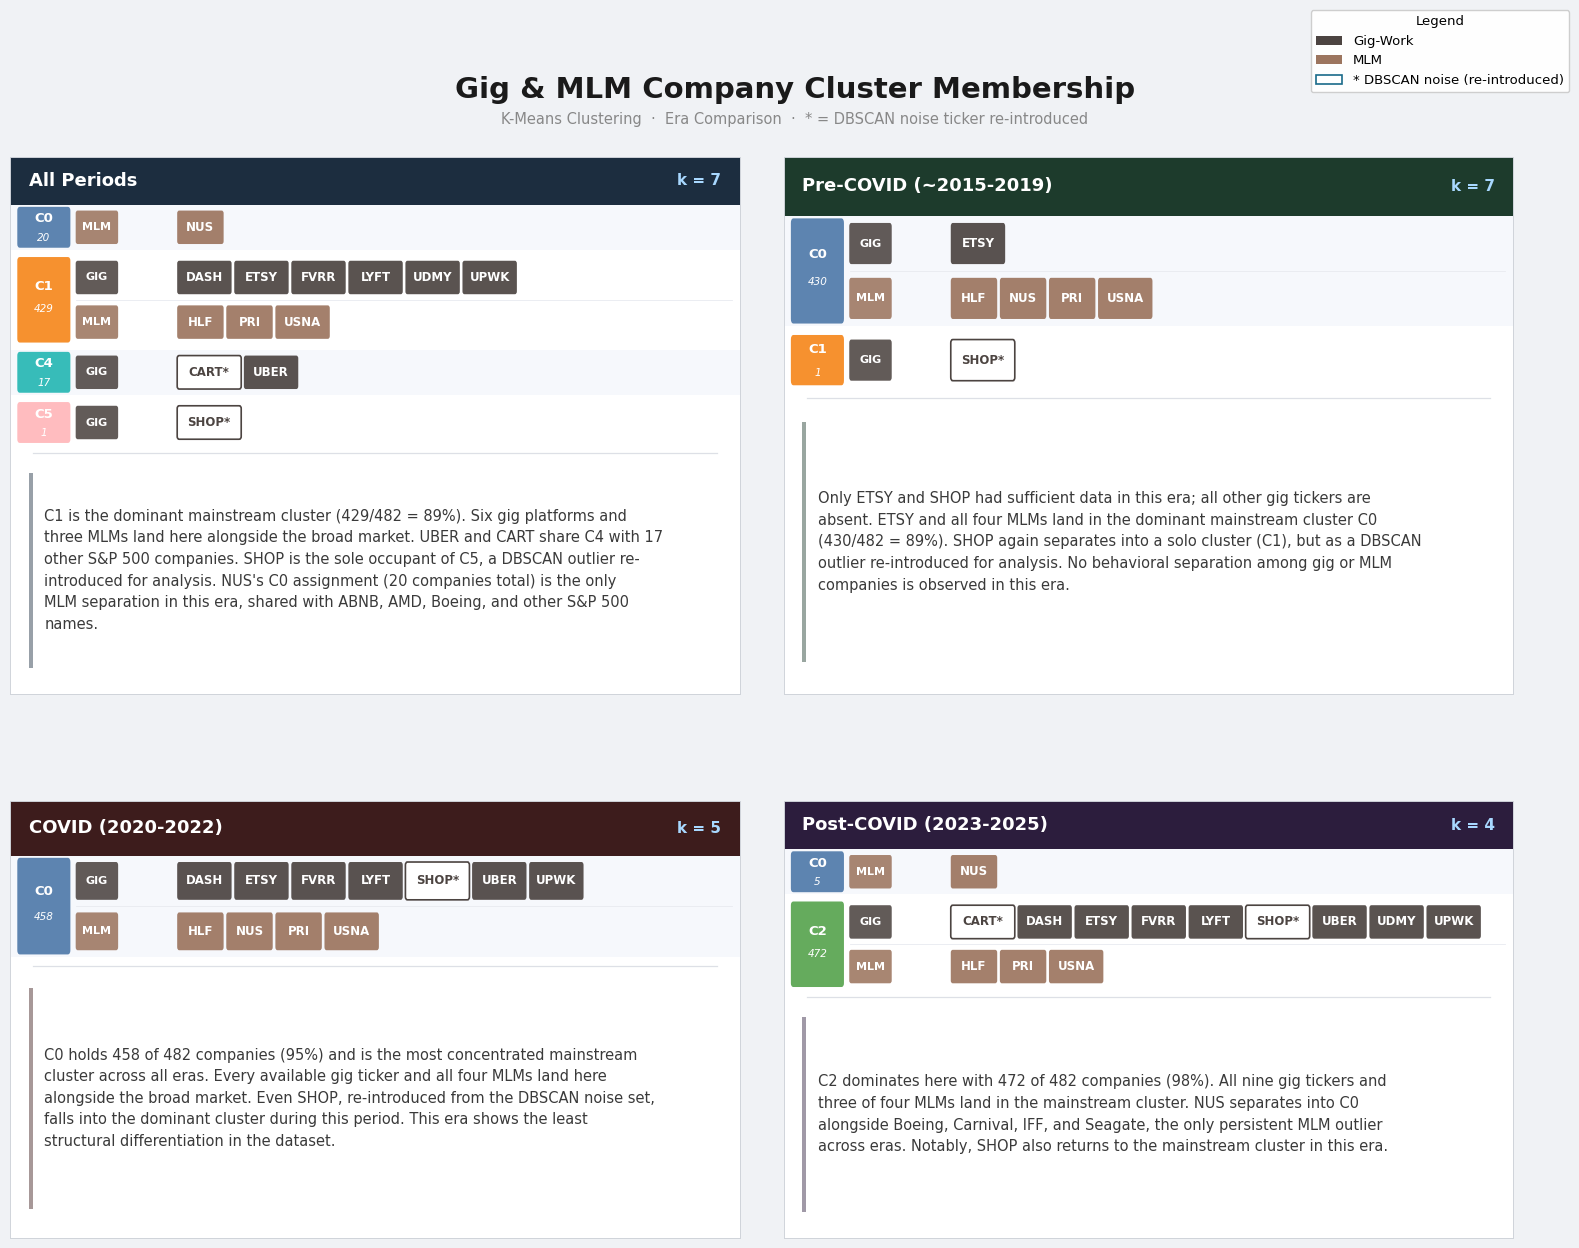

In [15]:

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, Rectangle
import textwrap

# NARRATIVE INSIGHTS
ERA_INSIGHTS = {
    'All Periods': (
        "C1 is the dominant mainstream cluster (429/482 = 89%). Six gig platforms "
        "and three MLMs land here alongside the broad market. UBER and CART share C4 "
        "with 17 other S&P 500 companies. SHOP is the sole occupant of C5, a DBSCAN "
        "outlier re-introduced for analysis. NUS's C0 assignment (20 companies total) "
        "is the only MLM separation in this era, shared with ABNB, AMD, Boeing, "
        "and other S&P 500 names."
    ),
    'Pre-COVID (~2015-2019)': (
        "Only ETSY and SHOP had sufficient data in this era; all other gig "
        "tickers are absent. ETSY and all four MLMs land in the dominant mainstream "
        "cluster C0 (430/482 = 89%). SHOP again separates into a solo cluster (C1), "
        "but as a DBSCAN outlier re-introduced for analysis. No behavioral separation "
        "among gig or MLM companies is observed in this era."
    ),
    'COVID (2020-2022)': (
        "C0 holds 458 of 482 companies (95%) and is the most concentrated mainstream "
        "cluster across all eras. Every available gig ticker and all four MLMs land "
        "here alongside the broad market. Even SHOP, re-introduced from the DBSCAN "
        "noise set, falls into the dominant cluster during this period. This era shows "
        "the least structural differentiation in the dataset."
    ),
    'Post-COVID (2023-2025)': (
        "C2 dominates here with 472 of 482 companies (98%). All nine gig tickers "
        "and three of four MLMs land in the mainstream cluster. NUS separates into "
        "C0 alongside Boeing, Carnival, IFF, and Seagate, the only persistent MLM "
        "outlier across eras. Notably, SHOP also returns to the mainstream cluster in this era."
    ),
}

# COLORS
CAT_LABELS = {'gig-work': 'GIG', 'mlm-work': 'MLM'}

ERA_HDR_CLR = {
    'All Periods':            '#1C2D3F',
    'Pre-COVID (~2015-2019)':  '#1D3B2C',
    'COVID (2020-2022)':      '#3D1C1C',
    'Post-COVID (2023-2025)': '#2C1D3D',
}

NOISE_TICKERS = {'SHOP', 'CART'}

_era_order = [
    'All Periods', 'Pre-COVID (~2015-2019)',
    'COVID (2020-2022)', 'Post-COVID (2023-2025)',
]

# LAYOUT
XLIM    = 11.0
HDR_H   = 0.52
SUB_H   = 0.48
CLR_GAP = 0.06
SEP_H   = 0.20
INS_H   = 2.30
PAD_BOT = 0.18

BDG_X0     = 2.55
BDG_CHAR_W = 0.145
BDG_MIN_W  = 0.64
BDG_H      = 0.30
BDG_GAP    = 0.10
PILL_W     = 0.72
CAT_TAG_W  = 0.58

F_ERA  = 13
F_K    = 11
F_PILL = 9.5
F_CSIZ = 7.5
F_CAT  = 8
F_BDG  = 8.5
F_INS  = 10.5
WRAP_W = 80

# HELPERS
def bdg_w(ticker):
    return max(len(ticker) * BDG_CHAR_W + 0.18, BDG_MIN_W)


def cluster_rows(era):
    edf = highlight_membership[
        (highlight_membership['Era'] == era)
        & (highlight_membership['Category'].isin(HIGHLIGHT_CATS))
    ]
    era_all  = combined_pca_df[combined_pca_df['Era'] == era]
    csz_dict = era_all.groupby('Cluster').size().to_dict()
    rows = []
    for cid in sorted(edf['Cluster'].unique(), key=lambda x: int(x)):
        cdf  = edf[edf['Cluster'] == cid].sort_values('Ticker')
        gig  = cdf[cdf['Category'] == 'gig-work']['Ticker'].tolist()
        mlm  = cdf[cdf['Category'] == 'mlm-work']['Ticker'].tolist()
        sz   = csz_dict.get(cid, csz_dict.get(str(cid), '?'))
        rows.append((str(cid), gig, mlm, sz))
    return rows


def panel_height(era):
    rows    = cluster_rows(era)
    n_subs  = sum((1 if g else 0) + (1 if m else 0) for _, g, m, _ in rows)
    n_clust = len(rows)
    return HDR_H + n_subs * SUB_H + (n_clust - 1) * CLR_GAP + SEP_H + INS_H + PAD_BOT


# FIGURE
ph    = [panel_height(e) for e in _era_order]
r0h   = max(ph[0], ph[1])
r1h   = max(ph[2], ph[3])
FIG_W = 16
FIG_H = (r0h + r1h) * 0.96 + 1.8

fig, axes = plt.subplots(
    2, 2, figsize=(FIG_W, FIG_H),
    gridspec_kw={'height_ratios': [r0h, r1h]},
)
fig.patch.set_facecolor('#F0F2F5')

fig.text(0.50, 0.979, 'Gig & MLM Company Cluster Membership',
         ha='center', fontsize=21, fontweight='bold', color='#1A1A1A')
fig.text(0.50, 0.957,
         'K-Means Clustering  ·  Era Comparison  ·  * = DBSCAN noise ticker re-introduced',
         ha='center', fontsize=10.5, color='#888888')

# PER-ERA PANELS
for idx, era in enumerate(_era_order):
    ri, ci = divmod(idx, 2)
    ax = axes[ri][ci]
    h  = ph[idx]

    ax.set_xlim(0, XLIM)
    ax.set_ylim(0, h)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor('#FFFFFF')
    for sp in ax.spines.values():
        sp.set_edgecolor('#D0D4DA')
        sp.set_linewidth(0.7)

    k    = era_optimal_k[era]
    rows = cluster_rows(era)

    # Header
    hb = h - HDR_H
    ax.add_patch(FancyBboxPatch(
        (0, hb), XLIM, HDR_H, boxstyle='square,pad=0',
        linewidth=0, facecolor=ERA_HDR_CLR[era],
    ))
    ax.text(0.28, hb + HDR_H / 2, era,
            color='white', fontsize=F_ERA, fontweight='bold', va='center')
    ax.text(XLIM - 0.28, hb + HDR_H / 2, f'k = {k}',
            color='#A8D8FF', fontsize=F_K, fontweight='bold', va='center', ha='right')

    # Cluster blocks
    y = hb
    for b_idx, (cid, gig_tickers, mlm_tickers, csz) in enumerate(rows):
        if b_idx > 0:
            y -= CLR_GAP
        clr     = PALETTE[int(cid) % len(PALETTE)]
        sub_cats = []
        if gig_tickers:
            sub_cats.append(('gig-work', gig_tickers))
        if mlm_tickers:
            sub_cats.append(('mlm-work', mlm_tickers))
        n_subs  = len(sub_cats)
        blk_h   = n_subs * SUB_H
        pill_top = y - blk_h + 0.06
        pill_h   = blk_h - 0.12
        pill_cx  = 0.15 + PILL_W / 2
        pill_cy  = y - blk_h / 2   # vertical centre of pill

        # Block background
        ax.add_patch(Rectangle(
            (0, y - blk_h), XLIM, blk_h,
            facecolor='#F6F8FC' if b_idx % 2 == 0 else '#FFFFFF',
            edgecolor='none', zorder=0,
        ))

        # Cluster ID pill
        ax.add_patch(FancyBboxPatch(
            (0.15, pill_top), PILL_W, pill_h,
            boxstyle='round,pad=0.04', facecolor=clr,
            linewidth=0, alpha=0.90, zorder=1,
        ))

        # Pill text: stack C{id} and size inside the pill
        if n_subs == 1:
            # Single sub-row — centre both lines vertically in the pill
            ax.text(pill_cx, pill_cy + 0.09, f'C{cid}',
                    color='white', fontsize=F_PILL, fontweight='bold',
                    va='center', ha='center', zorder=2)
            ax.text(pill_cx, pill_cy - 0.11, f'{csz}',
                    color='white', fontsize=F_CSIZ,
                    va='center', ha='center', zorder=2, style='italic')
        else:
            # Two sub-rows - more vertical room; stack with slightly larger gap
            ax.text(pill_cx, pill_cy + 0.14, f'C{cid}',
                    color='white', fontsize=F_PILL, fontweight='bold',
                    va='center', ha='center', zorder=2)
            ax.text(pill_cx, pill_cy - 0.10, f'{csz}',
                    color='white', fontsize=F_CSIZ,
                    va='center', ha='center', zorder=2, style='italic')

        # Sub-rows
        for s_idx, (cat, tickers) in enumerate(sub_cats):
            sy  = y - s_idx * SUB_H
            sym = sy - SUB_H / 2

            tc = _CAT_COLOR_MAP[cat]
            ax.add_patch(FancyBboxPatch(
                (1.02, sym - 0.15), CAT_TAG_W, 0.30,
                boxstyle='round,pad=0.03', facecolor=tc,
                linewidth=0, alpha=0.88, zorder=2,
            ))
            ax.text(1.02 + CAT_TAG_W / 2, sym, CAT_LABELS[cat],
                    color='white', fontsize=F_CAT, fontweight='bold',
                    va='center', ha='center', zorder=3)

            if s_idx > 0:
                ax.plot([1.00, XLIM - 0.12], [sy, sy],
                        color='#E8EAF0', linewidth=0.6, zorder=1)

            x = BDG_X0
            for tkr in tickers:
                is_noise = tkr in NOISE_TICKERS
                bw = bdg_w(tkr + ('*' if is_noise else ''))
                if is_noise:
                    ax.add_patch(FancyBboxPatch(
                        (x, sym - BDG_H / 2), bw, BDG_H,
                        boxstyle='round,pad=0.03',
                        facecolor='#FFFFFF', edgecolor=tc, linewidth=1.2, zorder=2,
                    ))
                    ax.text(x + bw / 2, sym, f'{tkr}*',
                            color=tc, fontsize=F_BDG, fontweight='bold',
                            va='center', ha='center', zorder=3)
                else:
                    ax.add_patch(FancyBboxPatch(
                        (x, sym - BDG_H / 2), bw, BDG_H,
                        boxstyle='round,pad=0.03', facecolor=tc,
                        linewidth=0, alpha=0.92, zorder=2,
                    ))
                    ax.text(x + bw / 2, sym, tkr,
                            color='white', fontsize=F_BDG, fontweight='bold',
                            va='center', ha='center', zorder=3)
                x += bw + BDG_GAP

        y -= blk_h

    # Separator
    sep_y = y - SEP_H * 0.45
    ax.plot([0.35, XLIM - 0.35], [sep_y, sep_y],
            color='#DDE0E6', linewidth=0.9, zorder=1)

    # Insight zone
    ins_mid = PAD_BOT + INS_H / 2
    ax.add_patch(Rectangle(
        (0.28, PAD_BOT + 0.10), 0.06, INS_H - 0.20,
        facecolor=ERA_HDR_CLR[era], edgecolor='none', alpha=0.45, zorder=1,
    ))
    wrapped = textwrap.fill(ERA_INSIGHTS.get(era, ''), width=WRAP_W)
    ax.text(0.52, ins_mid, wrapped,
            color='#3A3A3A', fontsize=F_INS, va='center',
            linespacing=1.55, zorder=2)

# Legend
legend_elements = [
    mpatches.Patch(facecolor=_CAT_COLOR_MAP['gig-work'], label='Gig-Work'),
    mpatches.Patch(facecolor=_CAT_COLOR_MAP['mlm-work'], label='MLM'),
    mpatches.Patch(facecolor='white', edgecolor='#1A6B8A',
                   linewidth=1.2, label='* DBSCAN noise (re-introduced)'),
]
fig.legend(
    handles=legend_elements, loc='lower right',
    bbox_to_anchor=(0.988, 0.978), fontsize=9.5,
    framealpha=0.95, edgecolor='#CCCCCC', fancybox=True,
    title='Legend', title_fontsize=9.5,
)

plt.tight_layout(rect=[0, 0.005, 1, 0.942])
plt.subplots_adjust(hspace=0.22, wspace=0.06)
# plt.savefig(
#     'cluster_membership_infographic.png', dpi=150,
#     bbox_inches='tight', facecolor=fig.get_facecolor(),
# )
plt.show()
